In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/daily_show_guests.csv')

df

,YEAR,GoogleKnowlege_Occupation,Show,Group,Raw_Guest_List
0,1999,actor,1/11/99,Acting,Michael J. Fox
1,1999,Comedian,1/12/99,Comedy,Sandra Bernhard
2,1999,television actress,1/13/99,Acting,Tracey Ullman
3,1999,film actress,1/14/99,Acting,Gillian Anderson
4,1999,actor,1/18/99,Acting,David Alan Grier
...,...,...,...,...,...
2688,2015,biographer,7/29/15,Media,Doris Kearns Goodwin
2689,2015,director,7/30/15,Media,J. J. Abrams
2690,2015,stand-up comedian,8/3/15,Comedy,Amy Schumer
2691,2015,actor,8/4/15,Acting,Denis Leary


In [3]:
def set_category(x):
    if x == 'Acting' or x == 'Comedy' or x == 'Musician':
        return 'Acting, Comedy, & Music'
    elif x == 'Media':
        return 'Media'
    elif x == 'Government' or x == 'Politician' or x == 'Political Aide':
        return 'Government and Politics'
    else:
        return ''
    

df['category'] = df['Group'].apply(set_category)

df = df[df['category'] != '']

df[['category', 'Group']]

,category,Group
0,"Acting, Comedy, & Music",Acting
1,"Acting, Comedy, & Music",Comedy
2,"Acting, Comedy, & Music",Acting
3,"Acting, Comedy, & Music",Acting
4,"Acting, Comedy, & Music",Acting
...,...,...
2688,Media,Media
2689,Media,Media
2690,"Acting, Comedy, & Music",Comedy
2691,"Acting, Comedy, & Music",Acting


In [4]:
fix_df = df.groupby(['YEAR', 'category']).size().reset_index(name='Count')


fix_df['proportion'] = (fix_df['Count'] / fix_df.groupby('YEAR')['Count'].transform('sum')) * 100
fix_df






,YEAR,category,Count,proportion
0,1999,"Acting, Comedy, & Music",150,92.024540
1,1999,Government and Politics,2,1.226994
2,1999,Media,11,6.748466
3,2000,"Acting, Comedy, & Music",125,78.125000
4,2000,Government and Politics,14,8.750000
5,2000,Media,21,13.125000
6,2001,"Acting, Comedy, & Music",114,76.000000
7,2001,Government and Politics,6,4.000000
8,2001,Media,30,20.000000
9,2002,"Acting, Comedy, & Music",99,66.442953


/var/folders/0m/mz993p495b15spz3qtwsz7jm0000gn/T/ipykernel_86357/1102563539.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


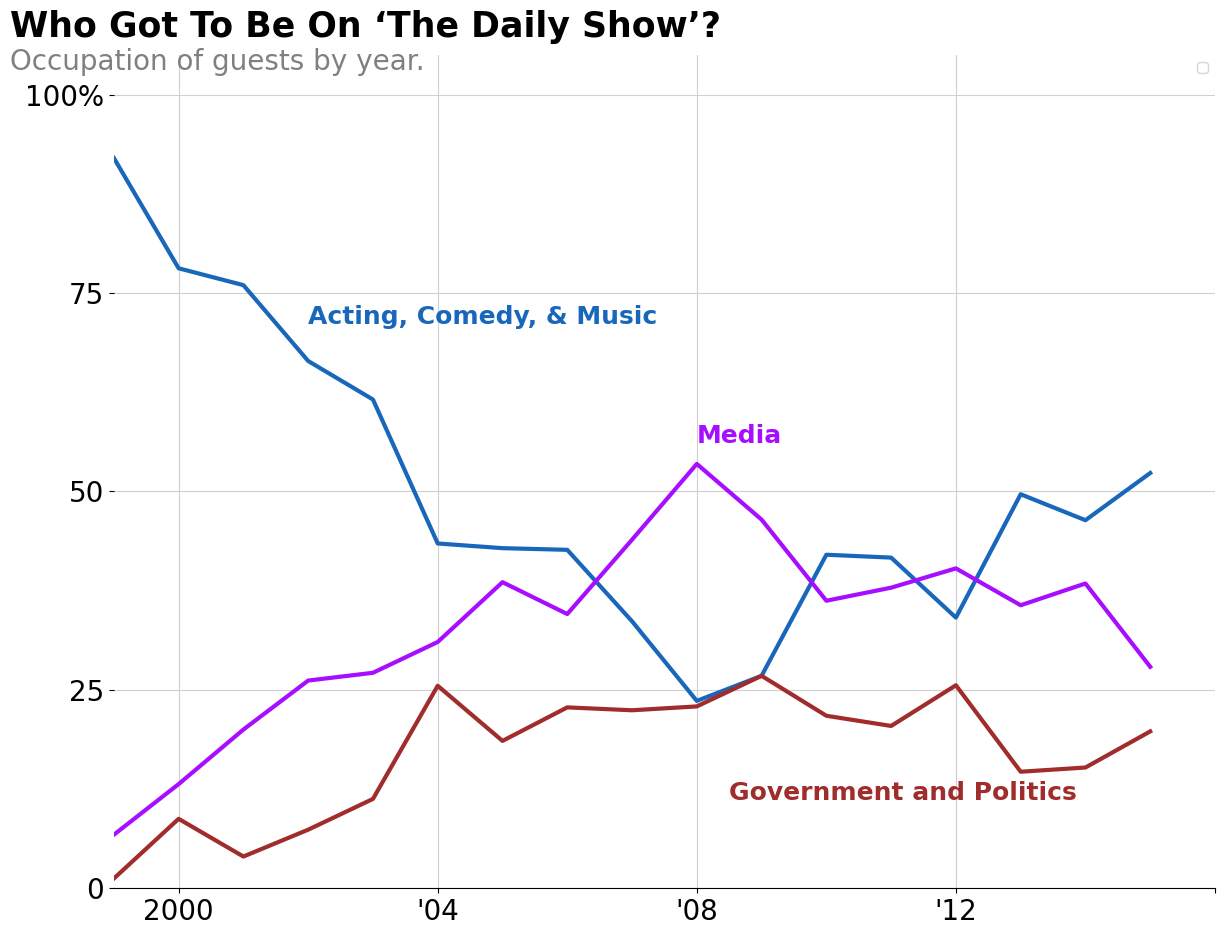

In [5]:

color_map = {
    'Acting, Comedy, & Music': "#1867bb",
    'Media': "#a70eff",
    'Government and Politics': "#a02c2c"
}

txt_placement = {
    'Acting, Comedy, & Music': [2002, 72],
    'Media': [2008, 57],
    'Government and Politics': [2008.5, 12]
    }


year = [2000, 2004, 2008, 2012, 2016]

percentage = [0, 25, 50, 75, 100]

fig, ax = plt.subplots(figsize=(12.2, 9.5))

ax.set_xlim(fix_df['YEAR'].min(), 2012)
ax.set_ylim(0, 105)

fig.suptitle(
    "Who Got To Be On ‘The Daily Show’?",
    fontsize=25,
    fontweight='bold',
    x=0,
    ha='left'
)

fig.text(0, 0.94, "Occupation of guests by year.", ha='left', va='top', fontsize=20, color='gray')



plt.xticks(ticks=year, labels=[2000, "'04", "'08", "'12", ''])

plt.yticks(ticks=percentage, labels = [0, 25, 50, 75, '100%'])

ax.tick_params(axis='both', labelsize=20)
for category, g in fix_df.groupby('category'):
    g = g.sort_values('YEAR')

    ax.plot(
        g['YEAR'],
        g['proportion'],
        color=color_map.get(category, 'gray'),
        linewidth=3
    )

    x_last = txt_placement[category][0]
    y_last = txt_placement[category][1]

    ax.text(
        x_last,
        y_last,
        category,
        color=color_map.get(category, 'black'),
        fontsize=18,
        fontweight='bold',
        va='center'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='y', color='#d0d0d0')
ax.set_ylabel('')

ax.grid(axis='y', color='#d0d0d0') 
ax.grid(axis='x', color='#d0d0d0')

    

plt.tight_layout()
plt.legend()
plt.show()
